In [ ]:
%pip install pandas kagglehub --quiet
import pandas as pd
import kagglehub as kh
import matplotlib.pyplot as plt


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\HP Probook 440 G7\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [107]:
import numpy as np

# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

100%|██████████| 1.25M/1.25M [00:00<00:00, 1.69MB/s]

Extracting files...


Path to dataset files: C:\Users\HP Probook 440 G7\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


In [5]:
import os
import pandas as pd

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [11]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [14]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

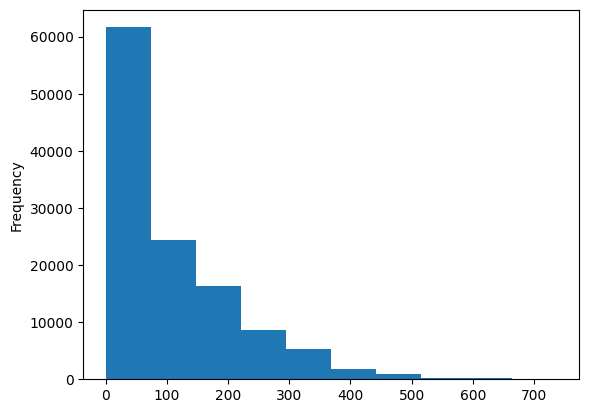

Skewness: 1.3465498727254268


count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [47]:
# frequency table
lead_time_series = pd.Series(df['lead_time'])
lead_time_series.plot.hist()
plt.show()

# skewness
lt_skew = df['lead_time'].skew()

print(f"Skewness: {lt_skew}")
df['lead_time'].describe()

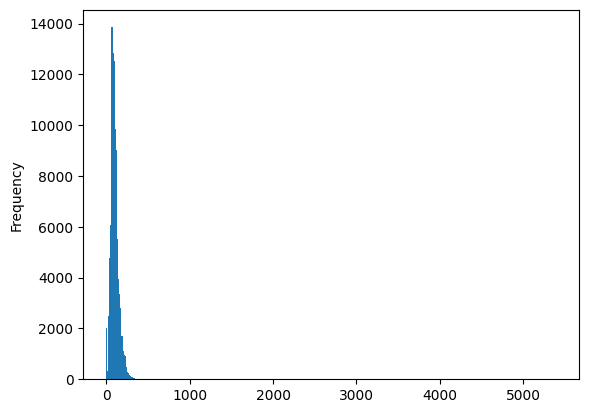

Skewness: 10.53021398218952


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [56]:
# frequency table
adr_series = pd.Series(df['adr'])
adr_series.plot.hist(bins=500)
plt.show()

# skewness
adr_skew = df['adr'].skew()

print(f"Skewness: {adr_skew}")
df['adr'].describe()

<Axes: >

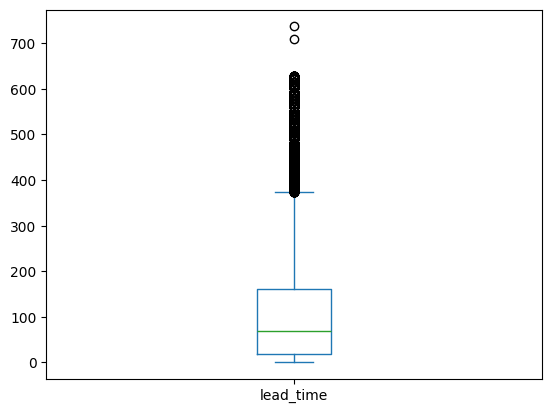

In [81]:
df['lead_time'].plot.box()

<Axes: >

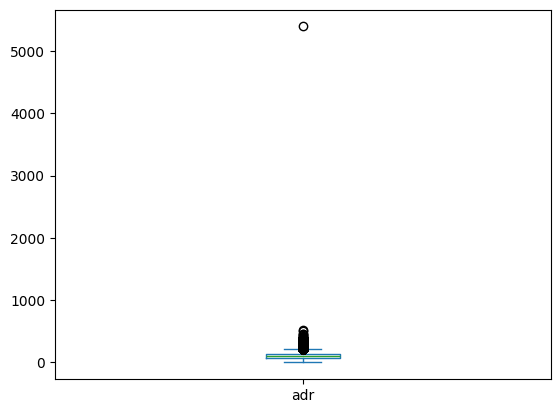

In [ ]:
df['adr'].plot.box()

## As we can see from the frequency distribution graph of ``lead time`` and ``average daily rate (adr)`` that they are both positive skew.
- lead time skewness: 1.34
- adr skewness: 10.53

there are more data that falls within left side of the range of the data
comparing lead time and adr skewness. ADR skewness is much greater stating that they are dominant outlier in the given column.

If we saw the frequency graph, summary statistics and boxplot of ``adr`` we can see the max is 5400, while the 75% quantile are under 126.0 seeing that huge distance of 126.0 and 5400. And using the frequency distribution graph we conclude that adr have some prominent outliers. For the ``lead time`` it showcase some outliers too from the jump of 75% quantile of 160.0 and to the max of 737.0



## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [86]:
count_cancel_count = df['is_canceled'].value_counts()


In [105]:
ques2 = df[['lead_time', 'is_canceled']]
ques2.describe()

,lead_time,is_canceled
count,119390.000000,119390.000000
mean,104.011416,0.370416
std,106.863097,0.482918
min,0.000000,0.000000
25%,18.000000,0.000000
50%,69.000000,0.000000
75%,160.000000,1.000000
max,737.000000,1.000000


<Axes: xlabel='lead_time', ylabel='is_canceled'>

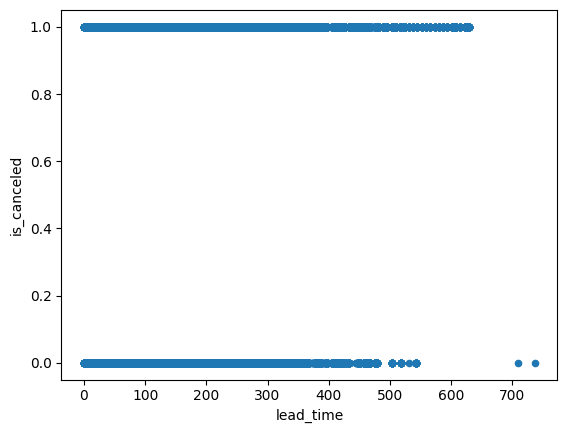

In [94]:
df.plot.scatter(x='lead_time', y='is_canceled')

In [89]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

## Based from the summary statistics and the ``is_canceled`` grouped lead_time mean. we can see that the mean of lead_time of bookings that are not canceled are around 79 days and the one canceled are 144 days. Showing the the greater the lead_time the higher chance of being canceled

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [125]:
city_df = df[df['hotel'] == 'City Hotel']
resort_df = df[df['hotel'] == 'Resort Hotel']

In [130]:
city_df_final = city_df.groupby('arrival_date_month')['adr'].mean()
city_df_final

arrival_date_month
April        111.251838
August       114.680455
December      88.826307
February      85.088278
January       82.628986
July         110.734292
June         119.074341
March         92.643116
May          121.638560
November      88.069601
October       99.974498
September    110.004661
Name: adr, dtype: float64

In [131]:
resort_df_final = resort_df.groupby('arrival_date_month')['adr'].mean()
resort_df_final

arrival_date_month
April         77.849496
August       186.790574
December      68.984230
February      55.171930
January       49.461883
July         155.181299
June         110.444749
March         57.520147
May           78.758134
November      48.273993
October       62.097617
September     93.252030
Name: adr, dtype: float64

<Axes: xlabel='arrival_date_month'>

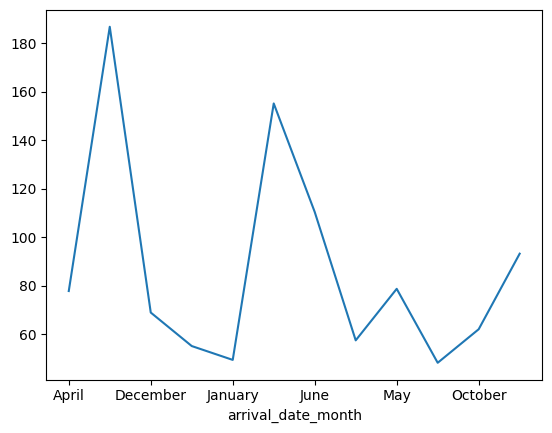

In [132]:
resort_df_final.plot.line(x='arrival_date_month', y='adr')

<Axes: xlabel='arrival_date_month'>

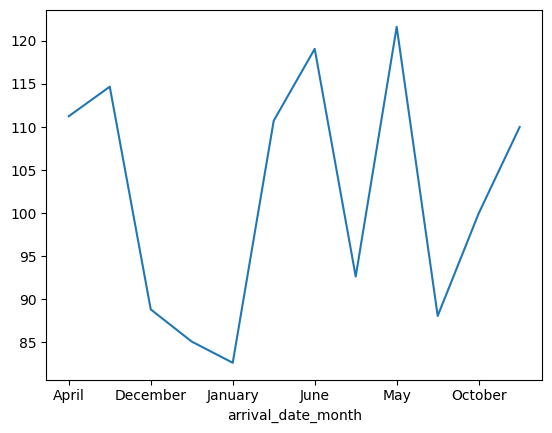

In [ ]:
arr = ['January', 'February', 'March', 'April', 'May', ' June', 'July', 'Auguest', 'September' 'October', 'November','December']
city_df_final.plot.line(x='arrival_date_month', y='adr')

In [137]:
seasons = df[['arrival_date_month', 'hotel', 'adr']]

result = seasons.groupby(['arrival_date_month', 'hotel']).agg(np.sum)



print(result)

                                        adr
arrival_date_month hotel                   
April              City Hotel     832163.75
                   Resort Hotel   280958.83
August             City Hotel    1030174.53
                   Resort Hotel   914153.07
December           City Hotel     367030.30
                   Resort Hotel   182670.24
February           City Hotel     422463.30
                   Resort Hotel   171198.50
January            City Hotel     308701.89
                   Resort Hotel   108469.91
July               City Hotel     895618.95
                   Resort Hotel   709644.08
June               City Hotel     939972.85
                   Resort Hotel   336304.26
March              City Hotel     598289.24
                   Resort Hotel   191887.21
May                City Hotel    1001328.63
                   Resort Hotel   280300.20
November           City Hotel     383719.25
                   Resort Hotel   117643.72
October            City Hotel   

C:\Users\HP Probook 440 G7\AppData\Local\Temp\ipykernel_11160\3731754437.py:3: FutureWarning: The provided callable <function sum at 0x000001D10FFA6FC0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  result = seasons.groupby(['arrival_date_month', 'hotel']).agg(np.sum)


In [ ]:
seasons = df[['arrival_date_month', 'hotel', 'adr']]

result = seasons.groupby(['arrival_date_month', 'hotel']).agg(np.mean)


print(result)

                                        adr
arrival_date_month hotel                   
April              City Hotel    111.251838
                   Resort Hotel   77.849496
August             City Hotel    114.680455
                   Resort Hotel  186.790574
December           City Hotel     88.826307
                   Resort Hotel   68.984230
February           City Hotel     85.088278
                   Resort Hotel   55.171930
January            City Hotel     82.628986
                   Resort Hotel   49.461883
July               City Hotel    110.734292
                   Resort Hotel  155.181299
June               City Hotel    119.074341
                   Resort Hotel  110.444749
March              City Hotel     92.643116
                   Resort Hotel   57.520147
May                City Hotel    121.638560
                   Resort Hotel   78.758134
November           City Hotel     88.069601
                   Resort Hotel   48.273993
October            City Hotel   

C:\Users\HP Probook 440 G7\AppData\Local\Temp\ipykernel_11160\1991266409.py:3: FutureWarning: The provided callable <function mean at 0x000001D10FFB0400> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result = seasons.groupby(['arrival_date_month', 'hotel']).agg(np.mean)


<Axes: xlabel='arrival_date_month,hotel'>

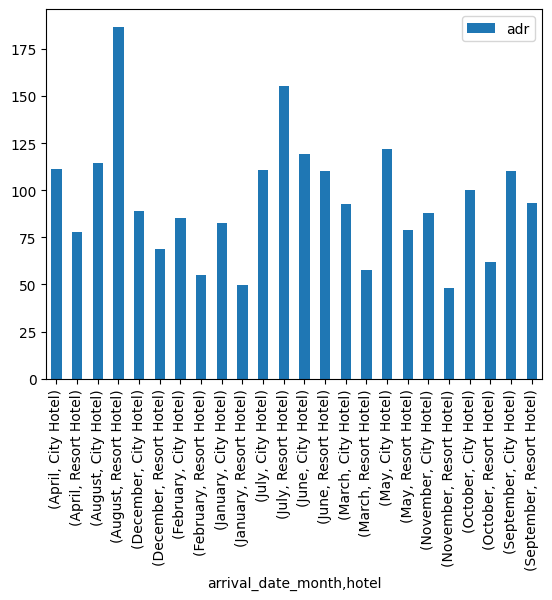

In [135]:
result.plot.bar()

In [149]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Based from the table and graphs, we can see that the seasons of summer has more increase in booking for resort hotel, and in comparison to it they are a surge of booking for the city hotel during winter

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [142]:
ques4 = df[['lead_time', 'booking_changes', 'is_repeated_guest']]
ques4.describe()

,lead_time,booking_changes,is_repeated_guest
count,119390.000000,119390.000000,119390.000000
mean,104.011416,0.221124,0.031912
std,106.863097,0.652306,0.175767
min,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000
50%,69.000000,0.000000,0.000000
75%,160.000000,0.000000,0.000000
max,737.000000,21.000000,1.000000


In [139]:
df['is_repeated_guest'].value_counts()

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64

In [143]:
not_repeated_df = df[df['is_repeated_guest'] == 0]
repeated_df = df[df['is_repeated_guest'] == 1]

In [158]:
adr_repeated_final = df.groupby('is_repeated_guest')['lead_time'].mean()
adr_repeated_final

is_repeated_guest
0    106.425221
1     30.786352
Name: lead_time, dtype: float64

In [159]:
adr_repeated_final = df.groupby('is_repeated_guest')['booking_changes'].mean()
adr_repeated_final

is_repeated_guest
0    0.219692
1    0.264567
Name: booking_changes, dtype: float64

## As we can see in the table of lead_time grouped by ``is_repeated_guest`` we can conclude that those who are repeated guest show more lower lead_time because they are really sure that the place is good and it is their basic go to

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


In [148]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [157]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


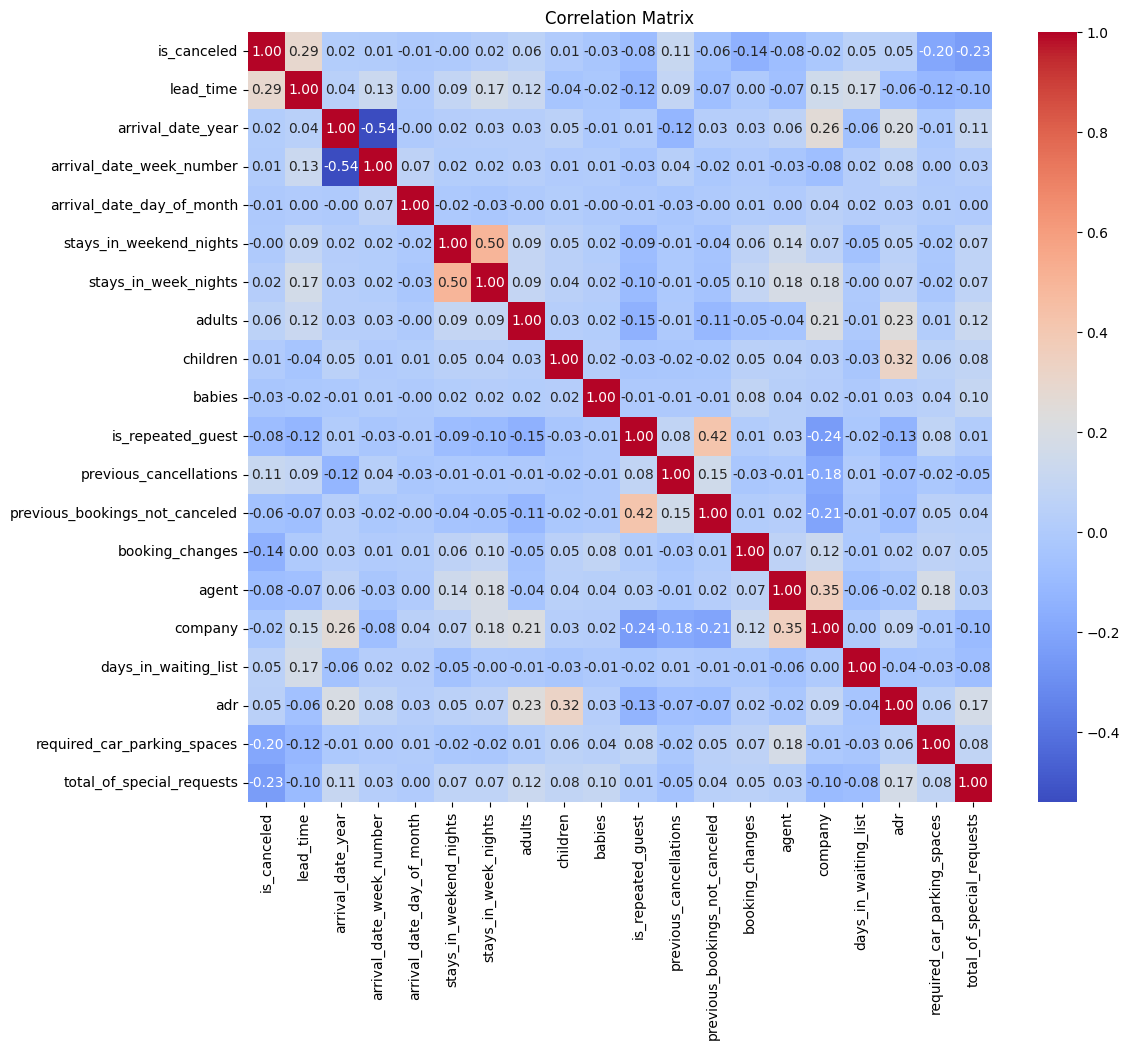

In [ ]:
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

## Based from the correlation matrix value that greatly affects the is_canceled are lead_time, required_car_parking_spaces, total_of_special_requests

``Lead time`` is a really factor given that long lead time mostly resort to changes of plans, for the ``required car parking spaces`` is often a followup inquiry after booking and if not fulfilled may result to cancellation same to guest with high ``total_of_special_requests``